Esse projeto tem o objetivo de estudar e analisar os dados do dataset sobre restaurantes em LA, sendo esses dados de código aberto. Por meio desse dataset, faremos uma pesquisa das condições atuais do mercado para descobrir se é possível obter sucesso ao abrir uma pequena cafeteria com garçons robôs em Los Angeles, já que é um negócio especial e desafiador. Por ser um projeto promissor e caro, iremos tentar atrair investidores, e por isso essa análise é voltada para atraí-los. A novidade dos robôs pode interessar os clientes no início, mas pode perder o apelo com o tempo, por isso os dados serão estudados com cautela, para que as recomendações sejam as mais seguras possíveis. O dataset possui as colunas do nome dos estabelecimentos (object_name), a coluna informando se são estabelecimentos de rede ou não (chain), a coluna com o tipo de estabelecimento (object_type), a coluna de endereço (address) e a coluna do número de assentos (number). 
Além disso, o presente projeto está dividido em três passos, sendo:
- Passo 1: Carregar os dados e prepará-los para a análise
- Passo 2: Análise de dados
- Passo 3: Preparação de uma apresentação.
 
Por meio dessa análise responderemos perguntas como:
- Qual tipo de estabelecimento é mais comum em LA?
- São os estabelecimentos de rede ou não redes que dominam o mercado?
- Qual tipo de estabelecimento é típico para redes?
- Qual o número ideal de assentos?

Entre outras perguntas para descobrir se é possível obter sucesso ao abrir uma pequena cafeteria com garçons robôs em Los Angeles.

# Passo 1. Carregando os dados e preparando-os para a análise

In [1]:
# Importando as bibliotecas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as st

In [2]:
# lendo o conjunto de dados do dataset sobre restaurantes em LA
restaurants_df = pd.read_csv('/datasets/rest_data_us_upd.csv', sep=',')

In [3]:
# Imprimindo as 5 primeiras linhas do dataset sobre restaurantes em LA
restaurants_df.head()

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20


In [4]:
# Imprimindo as 5 últimas linhas do dataset sobre restaurantes em LA
restaurants_df.tail()

,id,object_name,address,chain,object_type,number
9646,21432,HALL OF JUSTICE,217 W TEMPLE AVE,False,Restaurant,122
9647,21433,FIN-MELROSE,5750 MELROSE AVE,False,Restaurant,93
9648,21434,JUICY WINGZ,6741 HOLLYWOOD BLVD,True,Fast Food,15
9649,21435,MEDIDATE COFFEE,548 S SPRING ST STE 100,False,Cafe,6
9650,21436,CAFE SPROUTS,1300 S SAN PEDRO ST STE 111,True,Restaurant,19


In [5]:
# Imprimindo as informações do dataset sobre restaurantes em LA
restaurants_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   object
 2   address      9651 non-null   object
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   object
 5   number       9651 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 2.4 MB


Os tipos de dados das colunas estão corretos, exceto a coluna chain, que por apresentar valores True ou False faz mais sentido ser do tipo booleano ao invés de object. Logo, será necessário converter o tipo de dado. Além disso, observamos 3 valores ausentes na coluna chain. Logo, como são apenas 3 linhas com valores NaN em 9651 registros, faz mais sentido remover essas 3 linhas, já que remover não vai impactar a análise. Sendo assim, primeiro será preciso remover as linhas com NaN dessa coluna e depois fazer a conversão do tipo de dado.

In [6]:
# Removendo as linhas com valores ausentes da coluna chain do dataset sobre restaurantes em LA
restaurants_df = restaurants_df.dropna(subset=['chain'])

In [7]:
# Convertendo a coluna chain do dataset sobre restaurantes em LA de object para booleano
restaurants_df['chain'] = restaurants_df['chain'].astype('bool')
restaurants_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9648 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9648 non-null   int64 
 1   object_name  9648 non-null   object
 2   address      9648 non-null   object
 3   chain        9648 non-null   bool  
 4   object_type  9648 non-null   object
 5   number       9648 non-null   int64 
dtypes: bool(1), int64(2), object(3)
memory usage: 2.2 MB


Aqui podemos ver que ao remover os 3 valores ausentes da coluna chain e depois transformar o tipo de dado dessa coluna de object para booleano, a memória usada diminuiu de 2.4 MB para 2.2 MB.

In [8]:
# Verificando se há valores ausentes no dataset sobre restaurantes em LA 
restaurants_df.isna().sum()

id             0
object_name    0
address        0
chain          0
object_type    0
number         0
dtype: int64

In [9]:
# Verificando se há linhas completamente duplicadas no dataset sobre restaurantes em LA 
restaurants_df.duplicated().sum()

0

In [10]:
# Imprimindo um resumo estatístico das colunas numéricas do dataset sobre restaurantes em LA 
restaurants_df.describe()

,id,number
count,9648.000000,9648.000000
mean,16610.056385,43.703566
std,2786.049701,47.627252
min,11786.000000,1.000000
25%,14197.750000,14.000000
50%,16609.500000,27.000000
75%,19021.250000,46.000000
max,21436.000000,229.000000


In [11]:
# Mostrando o número de linhas e colunas do dataset sobre restaurantes em LA 
restaurants_df.shape

(9648, 6)

In [12]:
# Mostrando o nome das colunas do dataset sobre restaurantes em LA 
restaurants_df.columns

Index(['id', 'object_name', 'address', 'chain', 'object_type', 'number'], dtype='object')

Primeiramente, importei as bibliotecas, em seguida carreguei os dados sobre restaurantes em LA e chamei-o de restaurants_df. Foi verificado que os tipos de dados das colunas estavam corretos, exceto a coluna chain, que por apresentar valores True ou False, faz mais sentido ser do tipo booleano ao invés de object. Logo, foi necessário converter o tipo de dado. Além disso, observamos 3 valores ausentes na coluna chain. Como são apenas 3 linhas com valores NaN em 9651 registros, essas 3 linhas foram removidas, já que remover não impacta a análise. Sendo assim, primeiro foi preciso remover as linhas com NaN dessa coluna e depois ser feita a conversão do tipo de dado. Após a remoção dos valores ausentes da coluna chain e após transformar o tipo de dado dessa coluna de object para booleano, a memória usada diminuiu de 2.4 MB para 2.2 MB. Em seguida, foi feita a verificação quanto aos valores ausentes para certificar que não havia mais nenhuma linha com NaN e foi verificado também a ausência de duplicados. Por meio do método .describe() foi analisado que a média e a mediana apresentam uma diferença significativa, sendo a primeira em torno de 43.70 e a segunda de 27, indicando que a distribuição é assimétrica (provavelmente com alguns valores muito altos puxando a média para cima. Repara também que o máximo é 229, enquanto o 75% é apenas 46, o que sugere a presença de outliers. Ademais, por meio do método .columns verificou-se que as colunas já estavam com letra minúsculas e não havia espaço entre os nomes, não sendo necessário fazer conversões nesse sentido. 

# Passo 2. Análise de dados

In [13]:
# Encontrando o número de valores únicos na coluna object_type do dataset restaurants_df e como eles são distribuídos
ratio_establishments = restaurants_df['object_type'].value_counts(normalize=True).reset_index()
ratio_establishments['object_type'] = ratio_establishments['object_type'] * 100
print(ratio_establishments)

        index  object_type
0  Restaurant    75.176202
1   Fast Food    11.048922
2        Cafe     4.508706
3       Pizza     3.306385
4         Bar     3.026534
5      Bakery     2.933250


In [14]:
# Renomeando as colunas do DataFrame ratio_establishments
ratio_establishments = ratio_establishments.rename(columns={'index': 'establishments', 'object_type': 'proportion' })
print(ratio_establishments)

  establishments  proportion
0     Restaurant   75.176202
1      Fast Food   11.048922
2           Cafe    4.508706
3          Pizza    3.306385
4            Bar    3.026534
5         Bakery    2.933250


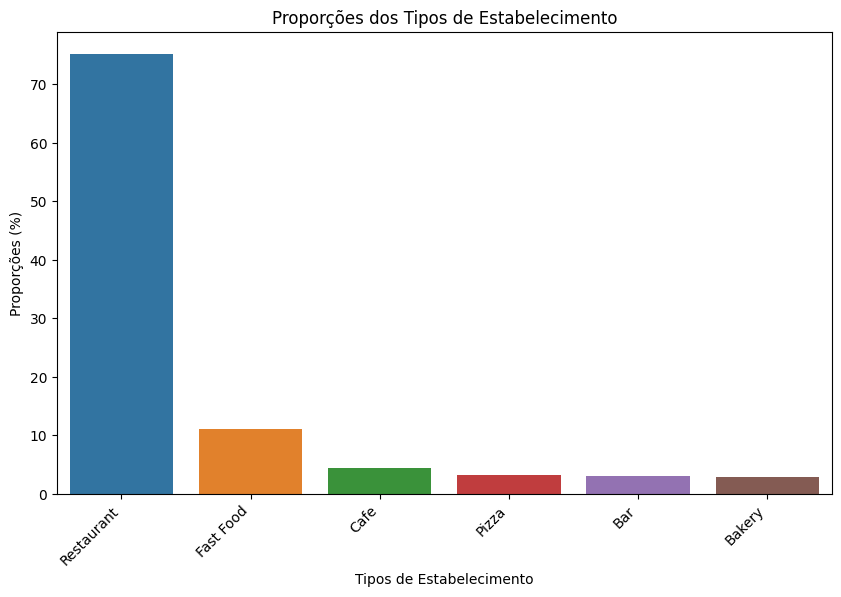

In [15]:
# Construindo um gráfico de barras que mostra as proporções de vários tipos de estabelecimentos
plt.figure(figsize=(10, 6))
sns.barplot(data=ratio_establishments, x='establishments', y='proportion')
plt.xticks(rotation=45, ha='right')
plt.title('Proporções dos Tipos de Estabelecimento')
plt.xlabel('Tipos de Estabelecimento')
plt.ylabel('Proporções (%)')
plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
plt.show()

Por meio do gráfico das proporções dos tipos de estabelecimento, podemos inferir que Restaurant possui a maior proporção, sendo ela em torno de 75.18%. O estabelecimento Fast Food ocupa o segundo lugar, com em torno de 11%. Os estabelecimentos Cafe, Pizza, Bar e Bakery ocupam proporções muito baixas, em torno de 4.51%, 3.31%, 3% e 2.93%, respectivamente. Dessa forma, concluímos que Restaurant é disparado o estabelecimento de maior proporção, o que pode significar muita concorrência no mercado, também pode indicar que há alta demanda dos consumidores por esse tipo de estabelecimento ou ainda que  pode ser simplesmente um reflexo de como os estabelecimentos são classificados no dataset. Por isso, será necessário estudar e analisar o contexto para descobrir o motivo da alta proporção de estabelecimentos Restaurant. Ademais, o fato de LA ser uma cidade conhecida por ter uma cultura forte de café e que há uma proporção de apenas 4.51% de cafeterias, indica uma concorrência baixa, o que pode ser uma excelente oportunidade de investimento.

In [16]:
# Encontrando o número de valores únicos na coluna chain do dataset restaurants_df e como eles são distribuídos
chain_store_ratios = restaurants_df['chain'].value_counts(normalize=True).reset_index()
chain_store_ratios['chain'] = chain_store_ratios['chain'] * 100
print(chain_store_ratios)

   index      chain
0  False  61.898839
1   True  38.101161


In [17]:
# Renomeando as colunas do DataFrame chain_store_ratios
chain_store_ratios = chain_store_ratios.rename(columns={'index': 'chain', 'chain': 'ratio' })
print(chain_store_ratios)

   chain      ratio
0  False  61.898839
1   True  38.101161


Concluímos que em torno de 38,1% dos estabelecimentos são de rede.

In [18]:
# Substituindo os valores True e False da coluna chain por Rede e Não Rede
chain_store_ratios['chain'] = chain_store_ratios['chain'].replace({True: 'Rede', False: 'Não Rede'})

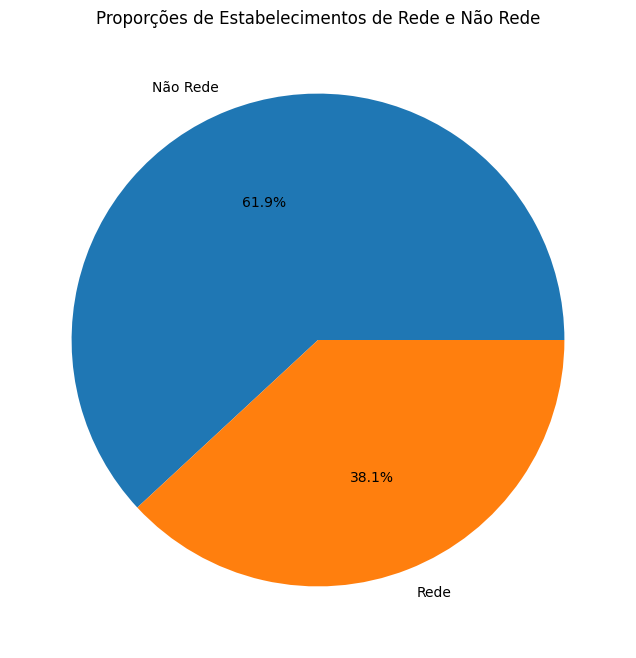

In [19]:
# Construindo um gráfico de pizza que mostra as proporções de estabelecimentos de rede e não rede
plt.figure(figsize=(8, 8))
plt.pie(chain_store_ratios['ratio'], labels=chain_store_ratios['chain'], autopct='%1.1f%%')
plt.title('Proporções de Estabelecimentos de Rede e Não Rede')
plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
plt.show()

Por meio do gráfico de pizza, podemos concluir que a maioria dos estabelecimentos (em torno de 61.9%) não são estabelecimentos de rede, enquanto 38.1% são estabelecimentos de rede. Isso pode ser explicado porque existem muitas barreiras para abrir uma franquia, podendo ter altos custos para serem abertas. Além disso, há regras, contratos e restrições para abrir uma franquia, o que dificulta a abertura. Ademais, LA é conhecida por uma forte cultura de negócios independentes e criativos e por isso há um foco maior em estabelecimentos não franquiados. Dessa forma, como a maioria dos estabelecimentos em LA não são de rede, uma franquia é menos comum, o que poderia ser uma oportunidade, já que há menos concorrência entre redes. Porém, dependerá do perfil do investidor, já que se for um investidor que prefere menos risco, seria melhor um estabelecimento de rede, enquanto que para um investidor que quer mais liberdade criativa, seria preferível um estabelecimento que não seja de rede.

In [20]:
# Filtrando os dados para ver apenas os estabelecimentos de rede
chain_restaurants = restaurants_df[restaurants_df['chain'] == True]
print(chain_restaurants)

         id               object_name                          address  chain  \
8     11794                ABC DONUTS  3027 N SAN FERNANDO RD UNIT 103   True   
10    11796             EL POLLO LOCO               5319 W SUNSET BLVD   True   
11    11797         POONG NYUN BAKERY        928 S WESTERN AVE STE 109   True   
12    11798  EMC RESTAURANT GROUP LLC            3500 W 6TH ST STE 101   True   
14    11800         CUSCATLECA BAKERY            2501 W SUNSET BLVD #A   True   
...     ...                       ...                              ...    ...   
9629  21415            JUCUAPA BAKERY             2810 JAMES WOOD BLVD   True   
9636  21422            CHIPOTLE #3094          6719 LA TIJERA BLVD A-B   True   
9639  21425                MCDONALD'S               1800 S WESTERN AVE   True   
9648  21434               JUICY WINGZ              6741 HOLLYWOOD BLVD   True   
9650  21436              CAFE SPROUTS      1300 S SAN PEDRO ST STE 111   True   

     object_type  number  


In [21]:
# Contando quantos estabelecimentos de rede existem por tipo 
count_establishments_per_type = chain_restaurants['object_type'].value_counts().reset_index()
print(count_establishments_per_type)

        index  object_type
0  Restaurant         2292
1   Fast Food          605
2      Bakery          283
3        Cafe          266
4       Pizza          153
5         Bar           77


In [22]:
# Renomeando as colunas do DataFrame count_establishments_per_type
count_establishments_per_type = count_establishments_per_type.rename(columns={'index': 'establishments', 'object_type': 'count_establishments_chain' })
print(count_establishments_per_type)

  establishments  count_establishments_chain
0     Restaurant                        2292
1      Fast Food                         605
2         Bakery                         283
3           Cafe                         266
4          Pizza                         153
5            Bar                          77


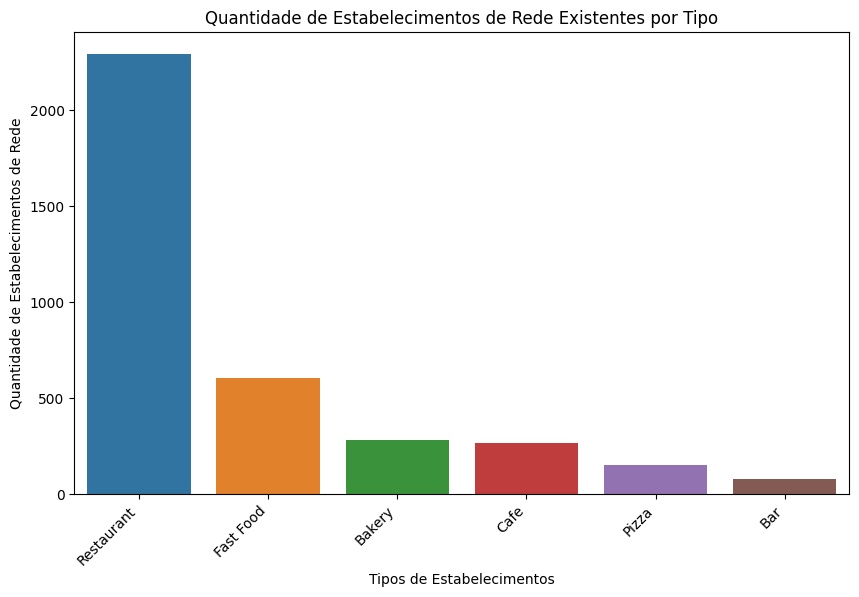

In [23]:
# Construindo um gráfico de barras que mostra quantos estabelecimentos de rede existem por tipo
plt.figure(figsize=(10,6))
sns.barplot(data=count_establishments_per_type, x='establishments', y='count_establishments_chain')
plt.xticks(rotation=45, ha='right')
plt.title('Quantidade de Estabelecimentos de Rede Existentes por Tipo')
plt.xlabel('Tipos de Estabelecimentos')
plt.ylabel('Quantidade de Estabelecimentos de Rede')
plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
plt.show()

Por meio do gráfico da quantidade de estabelecimentos de redes por tipo de estabelecimento, podemos concluir que Restaurant possui a maior quantidade de estabelecimentos de rede, sendo de 2292. Fast Food possui a segunda maior quantidade de estabelecimentos de rede, sendo de 605. Os estabelecimentos Bakery, Cafe, Pizza e Bar possuem menores quantidades, sendo elas de 283, 266, 153 e 77, respectivamente. Dessa forma, concluímos que Restaurant é disparado o que possui mais estabelecimentos de rede, podendo ser porque a categoria Restaurant é muito mais ampla e genérica do que as outras, o que inclui restaurantes italianos, mexicanos, americanos, japoneses, entre outros, ou seja, engloba mais tipos de negócios diferentes. Já Fast Food, Bakery, Cafe, Pizza e Bar são categorias muito mais específicas e limitadas. Dessa forma, há mais oportunidades para redes se estabelecerem na categoria Restaurant.

In [24]:
# Agrupando por object_name, contando o número de unidades de cada tipo de estabelecimento de rede e calculando a média de assentos por unidade
units_per_chain = chain_restaurants.groupby('object_name').agg({'object_type': 'count', 'number': 'mean'}) 
print(units_per_chain)

                           object_type  number
object_name                                   
#1 CHINESE FAST FOOD                 1     6.0
1810 RESTAURANT                      1    45.0
333                                  1   180.0
3RD ST MARKET & DELI                 1     7.0
4 CAMINOS RESTAURANT                 1    18.0
...                                ...     ...
ZANKOU CHICKEN                       2    53.5
ZEN BAKERY (RETAIL)                  1    19.0
ZERMENOS RESTAURANT INC              1    10.0
ZION MARKET DELI & ISLAND            1    16.0
ZIP SUSHI & IZAKAYA                  1    98.0

[2733 rows x 2 columns]


In [25]:
# Renomeando as colunas do DataFrame count_units_per_chain
units_per_chain = units_per_chain.rename(columns={'object_type': 'units', 'number': 'mean_seats'})
print(units_per_chain)

                           units  mean_seats
object_name                                 
#1 CHINESE FAST FOOD           1         6.0
1810 RESTAURANT                1        45.0
333                            1       180.0
3RD ST MARKET & DELI           1         7.0
4 CAMINOS RESTAURANT           1        18.0
...                          ...         ...
ZANKOU CHICKEN                 2        53.5
ZEN BAKERY (RETAIL)            1        19.0
ZERMENOS RESTAURANT INC        1        10.0
ZION MARKET DELI & ISLAND      1        16.0
ZIP SUSHI & IZAKAYA            1        98.0

[2733 rows x 2 columns]


In [26]:
# Ordenando a coluna mean_seats em ordem decrescente para ver quais redes têm mais assentos em média
units_per_chain.sort_values(by='mean_seats', ascending=False)

,units,mean_seats
object_name,,
MOUNTAINGATE COUNTRY CLUB,1,229.0
CHUCK E CHEESE'S #397,1,228.0
MCDONALD'S #5968,1,227.0
USC MAIN KITCHEN-BASEMENT,1,227.0
CHOSUN GALBEE RESTAURANT,1,226.0
...,...,...
EL GALLO BAKERY,1,1.0
CAFE CON LECHE BAKERY AND CAFE,1,1.0
BUMSAN ORGANIC MILK BAR,1,1.0


In [27]:
# Ordenando a coluna units em ordem decrescente para ver quais redes têm mais unidades
units_per_chain.sort_values(by='units', ascending=False).head(20)

,units,mean_seats
object_name,,
THE COFFEE BEAN & TEA LEAF,47,26.723404
SUBWAY,31,16.419355
DOMINO'S PIZZA,15,12.333333
WABA GRILL,14,42.857143
KENTUCKY FRIED CHICKEN,14,33.357143
MCDONALD'S,13,96.846154
TRIMANA,13,43.461538
STARBUCKS,12,18.000000
PAPA JOHN'S PIZZA,12,14.500000


Podemos observar que os estabelecimentos de rede com mais assentos têm poucos unidades (geralmente units = 1), sendo a média de assentos do líder de 229. Já o estabelecimento com mais unidades (47), sendo ele o The Coffee Bean & Tea Leaf, possui uma média baixa de assentos (em torno de 27). Além disso, o Subway, que possui o segundo maior número de unidades (31), possui uma média de 16 assentos e a Domino's Pizza, que possui 15 unidades, tem uma média de apenas 12 assentos. Dessa forma, as redes com mais unidades tendem a ter poucos assentos por unidade, e por isso o que caracteriza redes é o fato de haver muitos estabelecimentos com um pequeno número de assentos

In [28]:
# Agrupando por object_name e calculando a média de assentos para cada tipo de restaurante
mean_seats_per_type = restaurants_df.groupby('object_type')['number'].mean().reset_index()
print(mean_seats_per_type)

  object_type     number
0      Bakery  21.773852
1         Bar  44.767123
2        Cafe  25.000000
3   Fast Food  31.837711
4       Pizza  28.545455
5  Restaurant  48.048807


In [29]:
# Ordenando a coluna number em ordem decrescente para ver quais tipos de restaurantes tem a maior média de assentos
mean_seats_sorted = mean_seats_per_type.sort_values(by='number', ascending=False)
print(mean_seats_sorted)

  object_type     number
5  Restaurant  48.048807
1         Bar  44.767123
3   Fast Food  31.837711
4       Pizza  28.545455
2        Cafe  25.000000
0      Bakery  21.773852


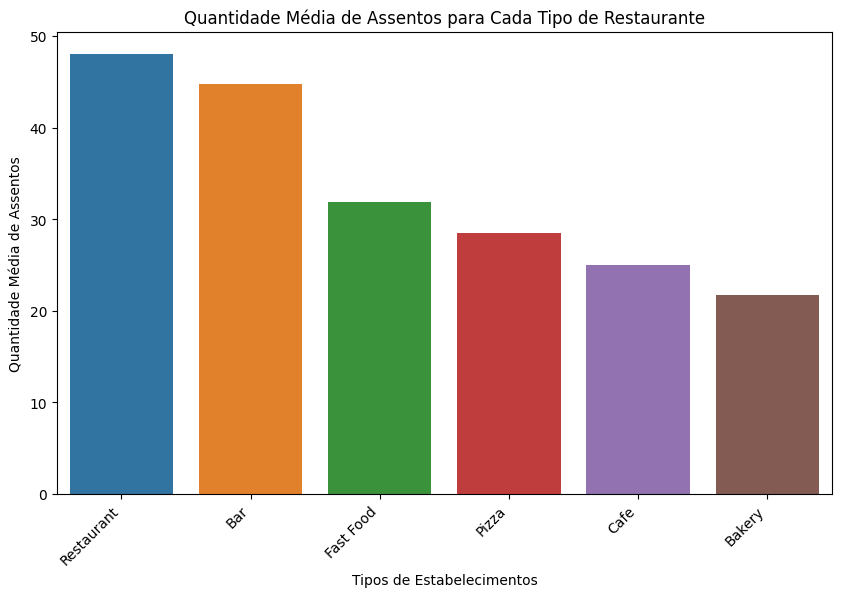

In [30]:
# Construindo um gráfico de barras que mostra a média de assentos para cada tipo de restaurante
plt.figure(figsize=(10,6))
sns.barplot(data=mean_seats_sorted, x='object_type', y='number')
plt.xticks(rotation=45, ha='right')
plt.title('Quantidade Média de Assentos para Cada Tipo de Restaurante')
plt.xlabel('Tipos de Estabelecimentos')
plt.ylabel('Quantidade Média de Assentos')
plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
plt.show()

Podemos observar no gráfico acima que o estabelecimento Restaurant possui o maior número médio de assentos, sendo em torno de 48. Em segundo lugar está a categoria Bar, com uma média de assentos em torno de 45. Fast Food ocupa a terceira posição, com uma média em torno de 32 assentos. As categorias Pizza, Cafe e Bakery ocupam as últimas posições, sendo a média de assentos em torno de 28, 25 e 22, respectivamente. O fato de Restaurant tem mais assentos em média pode ser explicado porque as pessoas geralmente quando vão à restaurantes consomem no local, e por isso o modelo de negócio depende de mesas ocupadas, já que quanto mais pessoas sentadas ao mesmo tempo, maior o faturamento, além do fato de que restaurantes costumam ter salões amplos, às vezes com múltiplos ambientes. Para a categoria Bar consideramos o mesmo raciocínio, já que as pessoas desfrutam do ambiente e tem um tempo maior de permanência, e por isso a quantidade média de assentos é parecida (em torno de 45) com a de Restaurant. Logo, em restaurantes a capacidade de assentos é diretamente ligada à receita do negócio, fazendo sentido investir em espaço. Em relação à Bakery e Cafe, é muito comum o takeway (comprar para levar), ou seja, o tempo de permanência dos clientes é muito menor do que em um restaurante. Nesse caso, o faturamento vem mais do volume de vendas rápidas do que de mesas ocupadas por horas. Isso significa que o espaço físico não precisa ser tão grande, e manter menos assentos reduz custos de aluguel e operação. Já as categorias Fast Food e Pizza apresentam um modelo de negócio misto, havendo opções takeaway e também opções para consumo no local, por isso elas ocupam uma posição mediana da quantidade de assentos em relação aos outros estabelecimentos.

In [31]:
# Colocando os dados dos nomes das ruas da coluna address em uma coluna separada
split_address = restaurants_df['address'].str.split(' ')
restaurants_df['street_name'] = split_address.str[1:].str.join(' ')
print(restaurants_df)

         id          object_name                      address  chain  \
0     11786  HABITAT COFFEE SHOP       3708 N EAGLE ROCK BLVD  False   
1     11787             REILLY'S            100 WORLD WAY 120  False   
2     11788       STREET CHURROS      6801 HOLLYWOOD BLVD 253  False   
3     11789    TRINITI ECHO PARK           1814 W SUNSET BLVD  False   
4     11790               POLLEN           2100 ECHO PARK AVE  False   
...     ...                  ...                          ...    ...   
9646  21432      HALL OF JUSTICE             217 W TEMPLE AVE  False   
9647  21433          FIN-MELROSE             5750 MELROSE AVE  False   
9648  21434          JUICY WINGZ          6741 HOLLYWOOD BLVD   True   
9649  21435      MEDIDATE COFFEE      548 S SPRING ST STE 100  False   
9650  21436         CAFE SPROUTS  1300 S SAN PEDRO ST STE 111   True   

     object_type  number             street_name  
0           Cafe      26       N EAGLE ROCK BLVD  
1     Restaurant       9         

In [32]:
# Contando a quantidade de restaurantes por rua
top_streets = restaurants_df['street_name'].value_counts().reset_index()
print(top_streets)

                      index  street_name
0             W SUNSET BLVD          296
1               W PICO BLVD          288
2            HOLLYWOOD BLVD          167
3             WILSHIRE BLVD          161
4             S VERMONT AVE          148
...                     ...          ...
3072  S FIGUEROA ST STE 103            1
3073    W COLLEGE ST UNIT E            1
3074        WILSHIRE BLVD I            1
3075    S GRAND AVE STE 101            1
3076        W MLK BLVD 106B            1

[3077 rows x 2 columns]


In [33]:
# Renomeando as colunas do DataFrame top_ten_streets e encontrando as top 10 ruas com o maior número de restaurantes
rename_top_streets = top_streets.rename(columns={'index': 'street_name', 'street_name': 'count_restaurants'})
top_ten_streets = rename_top_streets.head(10)
print(top_ten_streets)

         street_name  count_restaurants
0      W SUNSET BLVD                296
1        W PICO BLVD                288
2     HOLLYWOOD BLVD                167
3      WILSHIRE BLVD                161
4      S VERMONT AVE                148
5  SANTA MONICA BLVD                146
6           W 3RD ST                145
7       BEVERLY BLVD                135
8      S FIGUEROA ST                134
9        MELROSE AVE                128


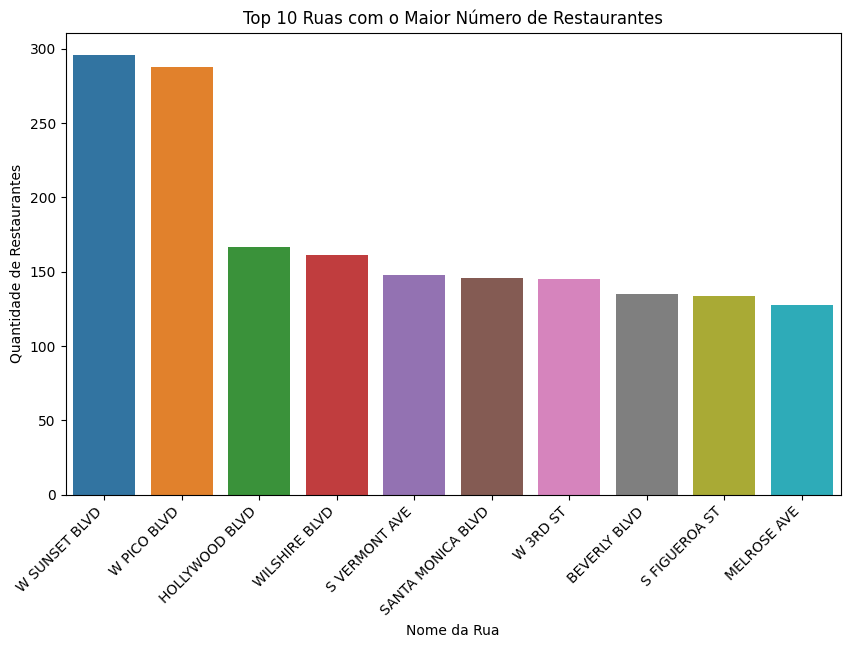

In [34]:
# Construindo um gráfico de barras que mostra as dez ruas com o maior número de restaurantes
plt.figure(figsize=(10,6))
sns.barplot(data=top_ten_streets, x='street_name', y='count_restaurants')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Ruas com o Maior Número de Restaurantes')
plt.xlabel('Nome da Rua')
plt.ylabel('Quantidade de Restaurantes')
plt.show()

Podemos concluir por meio do gráfico das dez ruas com o maior número de restaurantes que a rua com a maior quantidade é a W SUNSET BLVD, contendo 296 restaurantes. A rua W PICO BLVD ocupa o segundo lugar, com 288 restaurantes, ou seja, bem próximo da quantidade da rua que assume a liderança. Em seguida, a rua que ocupa a terceira posição é a HOLLYWOOD BLVD, com 167 restaurantes. As outras ruas analisadas tem quantidades de restaurantes mais parecidas entre si, sendo de 161, 148, 146, 145, 135, 134 e 128, ou seja, bem abaixo da quantidade apresentada pelas duas ruas que apresentam maior número (296 e 288). A rua que ocupa a última posição entre as 10 (S WESTERN AVE) contém apenas 128 restaurantes, ou seja, menos da metade da rua que ocupa a primeira posição (296). O fato da rua W SUNSET BLVD apresentar maior quantidade de restaurantes é devido ao fato dela ser uma das avenidas mais famosas de Los Angeles, sendo muito turística, bastante movimentada, repleta de atrações, além de ser uma avenida grande. Ademais, a rua W PICO BLVD também possui muitos restaurantes porque é uma avenida importante da cidade, conhecida por restaurantes, comércios e mercados, havendo bastante movimento.

In [35]:
# Filtrando as ruas com apenas 1 restaurante
streets_one_rest = rename_top_streets[rename_top_streets['count_restaurants'] == 1]
print(len(streets_one_rest))

2450


Podemos concluir que de 3077 ruas, 2450 têm apenas 1 restaurante. Isso significa que aproximadamente 80% das ruas têm apenas 1 restaurante, ou seja, os restaurantes estão bastante espalhados pela cidade. Dessa forma inferimos que em 80% das ruas há apenas 1 restaurante, logo menos concorrência, mas talvez menos movimento de pessoas. Já os outros 20% das ruas contém muitos restaurantes, logo mais concorrência, mas provavelmente mais fluxo de clientes.

In [36]:
# Filtrando as ruas com mais de 1 restaurante
streets_multiple_rest = rename_top_streets[rename_top_streets['count_restaurants'] > 1]
print(len(streets_multiple_rest))

627


Podemos concluir que de 3077 ruas, 627 têm mais de 1 restaurante. 

In [37]:
# Filtrar o DataFrame restaurants_df para pegar apenas os restaurantes que estão nas ruas com mais de 1 restaurante 
rest_isin_multiple_rest = restaurants_df[restaurants_df['street_name'].isin(streets_multiple_rest['street_name'])]
print(rest_isin_multiple_rest)

         id          object_name                 address  chain object_type  \
0     11786  HABITAT COFFEE SHOP  3708 N EAGLE ROCK BLVD  False        Cafe   
3     11789    TRINITI ECHO PARK      1814 W SUNSET BLVD  False  Restaurant   
4     11790               POLLEN      2100 ECHO PARK AVE  False  Restaurant   
5     11791       THE SPOT GRILL     10004 NATIONAL BLVD  False  Restaurant   
9     11795             UPSTAIRS    3707 N CAHUENGA BLVD  False  Restaurant   
...     ...                  ...                     ...    ...         ...   
9642  21428               TOLOSA      2635 WHITTIER BLVD  False  Restaurant   
9643  21429          DIVINE DIPS    601 S LOS ANGELES ST  False  Restaurant   
9644  21430      LA BUFADORA BAR           3470 E 1ST ST  False         Bar   
9647  21433          FIN-MELROSE        5750 MELROSE AVE  False  Restaurant   
9648  21434          JUICY WINGZ     6741 HOLLYWOOD BLVD   True   Fast Food   

      number        street_name  
0         26  N E

Há 7198 restaurantes localizados em ruas com mais de 1 restaurante.

In [38]:
# Somando o número de assentos para as ruas com mais de um restaurante
count_seats_multiple_rests = rest_isin_multiple_rest.groupby('street_name')['number'].sum().reset_index()
print(count_seats_multiple_rests)

           street_name  number
0     1/2 BEVERLY BLVD      86
1         1/2 E 1ST ST     217
2     1/2 FLORENCE AVE      38
3    1/2 HILLHURST AVE      16
4     1/2 HYPERION AVE      28
..                 ...     ...
622      WORLD WAY T71     349
623          YORK BLVD    2101
624        YOSEMITE DR      32
625           YUCCA ST      90
626          ZONAL AVE     253

[627 rows x 2 columns]


In [39]:
# Calculando o número de bins para o histograma
n = len(rest_isin_multiple_rest)
bins = int(np.sqrt(n)) 
print(bins)

84


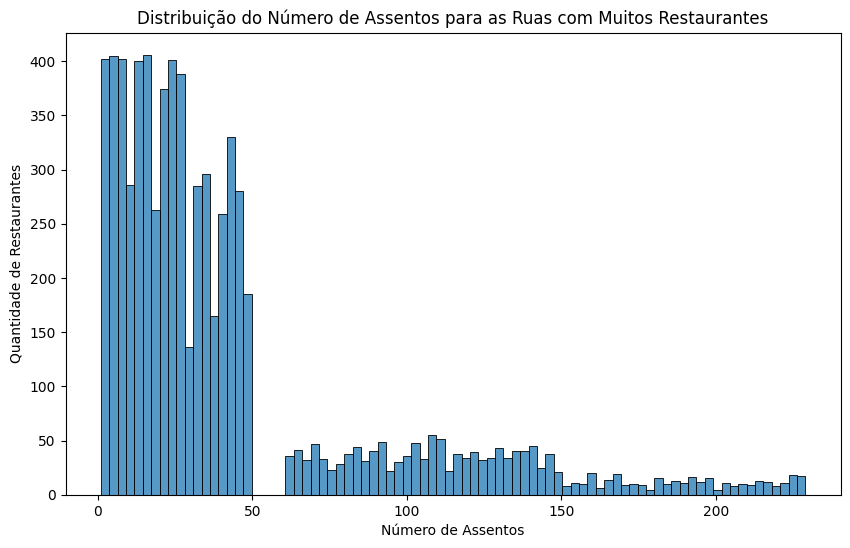

In [40]:
# Criando um histograma para a distribuição do número de assentos para as ruas com muitos restaurantes
plt.figure(figsize=(10, 6))
sns.histplot(data=rest_isin_multiple_rest, x='number', bins=bins)
plt.title('Distribuição do Número de Assentos para as Ruas com Muitos Restaurantes')
plt.xlabel('Número de Assentos')
plt.ylabel('Quantidade de Restaurantes')
plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
plt.show()

O histograma da distribuição do número de assentos para as ruas com muitos restaurantes mostra uma distribuição assimétrica à direita (positiva), já que a cauda é mais longa para o lado direito, ou seja, a maioria dos valores está concentrada à esquerda (valores menores). As barras mais altas estão entre 0 e 50 assentos aproximadamente, o que significa que a maioria dos restaurantes nas ruas com muitos restaurantes tem um número pequeno de assentos (entre 0 e 50). Além disso, podemos inferir que restaurantes com muitos assentos são mais raros. Isso explica a assimetria à direita, já que a cauda longa do lado direito representa esses restaurantes raros com muitos assentos. Dessa forma, concluímos que a maioria dos restaurantes em LA tem poucos assentos.

In [41]:
# Filtrando o DataFrame para descobrir quais ruas têm mais cafés
cafe = restaurants_df[restaurants_df['object_type'] == 'Cafe']
print(cafe)

         id                object_name                   address  chain  \
0     11786        HABITAT COFFEE SHOP    3708 N EAGLE ROCK BLVD  False   
53    11839         PRIME GRIND COFFEE              714 W 1ST ST  False   
102   11888               CIVIL COFFEE        5629 N FIGUEROA ST  False   
121   11907    ANTIGUA CULTURAL COFFEE        3400 N FIGUEROA ST  False   
123   11909    MARIE'S COFFEE AND DELI              731 W 7TH ST   True   
...     ...                        ...                       ...    ...   
9598  21384      GOOD PEOPLE COFFEE CO   11609 SANTA MONICA BLVD  False   
9610  21396   TERRAZA CAFE COFFEE SHOP  4017 1/2 CITY TERRACE DR  False   
9623  21409         310 COFFEE COMPANY       11623 WASHINGTON PL  False   
9635  21421  THE TEA & COFFEE EXCHANGE   6801 HOLLYWOOD BLVD 120  False   
9649  21435            MEDIDATE COFFEE   548 S SPRING ST STE 100  False   

     object_type  number          street_name  
0           Cafe      26    N EAGLE ROCK BLVD  
53 

In [42]:
# Contando quantos cafés existem por rua
cafe_per_street = cafe['street_name'].value_counts().reset_index()
top_ten_cafe_per_street = cafe_per_street.head(10)
print(top_ten_cafe_per_street)

               index  street_name
0      W SUNSET BLVD           21
1        W PICO BLVD           11
2          WORLD WAY           10
3  SANTA MONICA BLVD            8
4     HOLLYWOOD BLVD            7
5      WESTWOOD BLVD            7
6        S GRAND AVE            6
7       BEVERLY BLVD            6
8      S FIGUEROA ST            5
9           W 6TH ST            5


In [43]:
# Renomeando as colunas do DataFrame top_ten_cafe_per_street e encontrando as top 10 ruas com o maior número de cafés
rename_top_ten_cafe = top_ten_cafe_per_street.rename(columns={'index': 'street_name', 'street_name': 'count_cafes'})
print(rename_top_ten_cafe)

         street_name  count_cafes
0      W SUNSET BLVD           21
1        W PICO BLVD           11
2          WORLD WAY           10
3  SANTA MONICA BLVD            8
4     HOLLYWOOD BLVD            7
5      WESTWOOD BLVD            7
6        S GRAND AVE            6
7       BEVERLY BLVD            6
8      S FIGUEROA ST            5
9           W 6TH ST            5


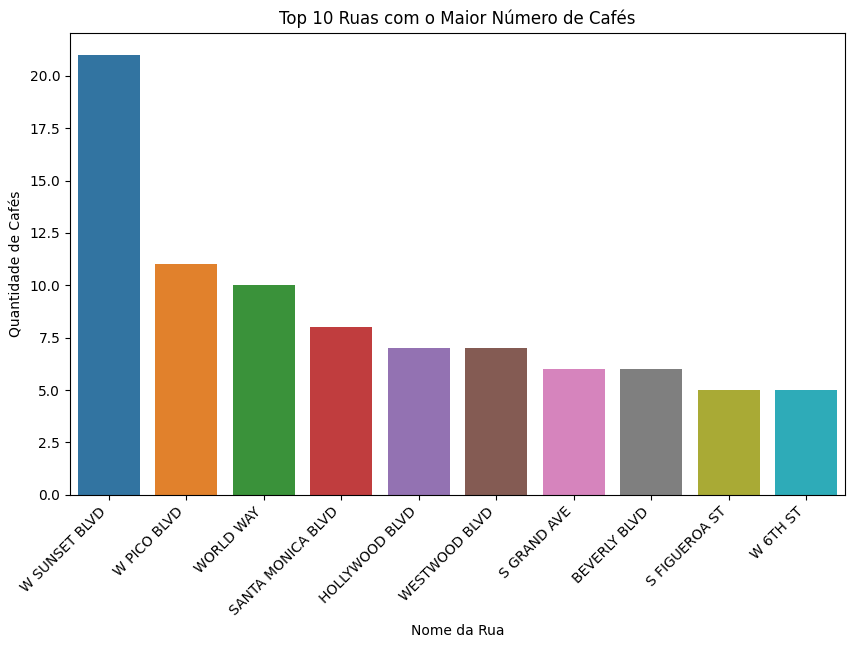

In [44]:
# Construindo um gráfico de barras que mostra as dez ruas com o maior número de cafés
plt.figure(figsize=(10,6))
sns.barplot(data=rename_top_ten_cafe, x='street_name', y='count_cafes')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Ruas com o Maior Número de Cafés')
plt.xlabel('Nome da Rua')
plt.ylabel('Quantidade de Cafés')
plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
plt.show()

A análise das top dez ruas com o maior número de cafés mostrou que a rua W SUNSET BLVD possui disparado o maior número (em torno de 21), ocupando a liderança assim como nas top 10 ruas com maior número de restaurantes em geral. A segunda posição é ocupada pela rua W PICO BLVD, que possui 11 cafés, ocupando o segundo lugar assim como nas top 10 ruas com maior número de restaurantes em geral. Como vimos, essas duas ruas são muito movimentadas e são ruas grandes, o que explica os números altos. Já a terceira posição é ocupada pela rua WORLD WAY, com 10 cafés. Essa rua, por ser a via principal que circula os terminais do Aeroporto Internacional de Los Angeles, é muito movimentada, por isso há uma quantidade alta de cafés. Entre as 10 ruas com mais cafés, a rua WILSHIRE BLVD ocupa a última posição, com 5 cafés, além da rua W 6TH ST que também possui 5 cafés. As ruas SANTA MONICA BLVD e BEVERLY BLVD aparecem tanto nas top 10 ruas com o maior número de restaurantes tanto nas top 10 ruas com mais número de cafés.

In [45]:
# Encontrando o número de valores únicos na coluna chain do dataset cafe e como eles são distribuídos
chain_cafe_ratios = cafe['chain'].value_counts(normalize=True).reset_index()
chain_cafe_ratios['chain'] = chain_cafe_ratios['chain'] * 100
print(chain_cafe_ratios)

   index      chain
0   True  61.149425
1  False  38.850575


In [46]:
# Renomeando as colunas do DataFrame chain_cafe_ratios
chain_cafe_ratios = chain_cafe_ratios.rename(columns={'index': 'chain_cafe', 'chain': 'ratio_cafe' })
print(chain_cafe_ratios)

   chain_cafe  ratio_cafe
0        True   61.149425
1       False   38.850575


In [47]:
# Substituindo os valores True e False da coluna chain_cafe por Rede e Não Rede
chain_cafe_ratios['chain_cafe'] = chain_cafe_ratios['chain_cafe'].replace({True: 'Rede', False: 'Não Rede'})

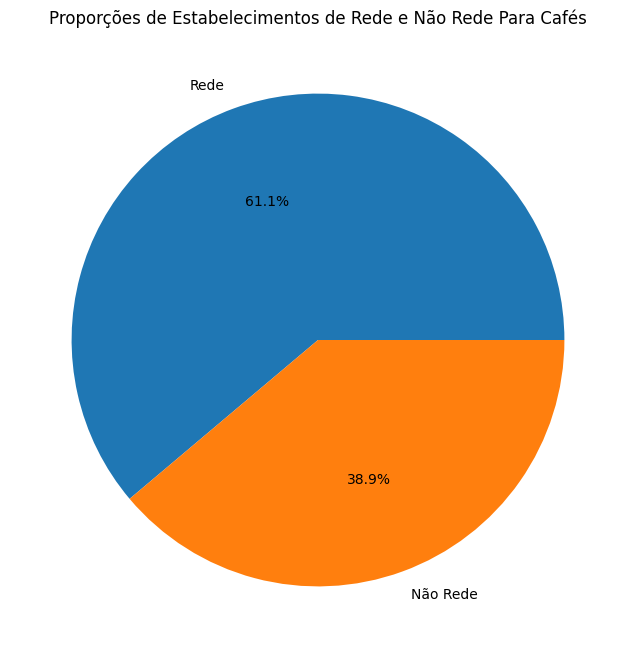

In [48]:
# Construindo um gráfico de pizza que mostra as proporções de estabelecimentos de rede e não rede para cafés
plt.figure(figsize=(8, 8))
plt.pie(chain_cafe_ratios['ratio_cafe'], labels=chain_cafe_ratios['chain_cafe'], autopct='%1.1f%%')
plt.title('Proporções de Estabelecimentos de Rede e Não Rede Para Cafés')
plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
plt.show()

Apenas 38.1% dos estabelecimentos são de rede, mas o gráfico mostra que especificamente para Cafe, 61.1% são de rede. Isso é uma informação relevante, significando que, dentro da categoria Cafe, redes dominam. O fato 61% dos cafés em LA serem de rede indica que o modelo de rede funciona bem para esse tipo de negócio, não que o mercado está saturado, até porque cafés representam apenas 4.51% do total de estabelecimentos.

# Conclusão
Por meio das análises realizadas constatamos que o estabelecimento mais comum em LA é Restaurant, com proporção em torno de 75.18%. Já Cafe ocupa proporções muito baixas, em torno de 4.51%, revelando uma concorrência baixa no mercado, podendo indicar também baixa demanda. Além disso, verificamos que o estabelecimento Cafe tem uma média de 25 assentos. Ademais, constatou-se que apenas 38.1% dos estabelecimentos são de rede e que redes com mais unidades (como The Coffee Bean & Tea Leaf e Subway, com 47 e 31 unidades, respectivamente) tendem a ter poucos assentos por unidade. Inferimos que em 80% das ruas há apenas 1 restaurante, logo menos concorrência, mas talvez menos movimento de pessoas. Já os outros 20% das ruas contém muitos restaurantes, logo mais concorrência, mas provavelmente mais fluxo de clientes. Por meio de histograma constatamos que a maioria dos restaurantes nas ruas com muitos restaurantes tem um número pequeno de assentos (entre 0 e 50). A análise das top dez ruas com o maior número de cafés mostrou que a rua W SUNSET BLVD possui disparado o maior número (em torno de 21), ocupando a liderança, assim como nas top 10 ruas com maior número de restaurantes em geral. A segunda posição é ocupada pela rua W PICO BLVD, que possui 11 cafés, ocupando a mesma posição nas top 10 ruas com maior número de restaurantes em geral. Como vimos, essas duas ruas são muito movimentadas e são ruas grandes, o que explica os números altos. Já a terceira posição é ocupada pela rua WORLD WAY, com 10 cafés. Essa rua, por ser a via principal que circula os terminais do Aeroporto Internacional de Los Angeles, é muito movimentada, por isso há uma quantidade alta de cafés. Entre as 10 ruas com mais cafés, a rua WILSHIRE BLVD ocupa a última posição, com 5 cafés, além da rua W 6TH ST que também possui 5 cafés. As ruas SANTA MONICA BLVD e BEVERLY BLVD aparecem tanto nas top 10 ruas com o maior número de restaurantes tanto nas top 10 ruas com mais número de cafés.
Dessa forma, como o estabelecimento Cafe tem pouca concorrência (proporção de 4.51%), além de que há uma cultura da maioria dos estabelecimentos terem poucos assentos, inclusive o fato de Cafe ter em média 25 assentos. Ademais, apenas 38.1% dos estabelecimentos são de rede, mas especificamente para Cafe, 61.1% são de rede. Sendo assim, a sugestão é a abertura de uma rede de Cafe de múltiplas unidades com poucos assentos (de 25 até 50, conforme estudo mostrado no histograma do número de assentos para ruas com muitos restaurantes e conforme o The Coffee Bean & Tea Leaf, que é o estabelecimento de rede com maior quantidade de unidades, sendo 47 unidades). Essa ideia é interessante já que uma cafeteria com garçons robôs, por ser um conceito inovador, pode perder o apelo com o tempo em uma única unidade, já com múltiplas unidades é possível escalar o investimento em tecnologia (robôs) de forma mais eficiente. 
Além disso, uma rede fortalece o reconhecimento da marca. O fato 61.1% dos cafés em LA serem de rede indica que o modelo de rede funciona bem para esse tipo de negócio, não que o mercado está saturado, até porque cafés representam apenas 4.51% do total de estabelecimentos. O fato de LA ser uma cidade conhecida por ter uma cultura forte de café e que há uma proporção de apenas 4.51% de cafeterias, indica uma concorrência baixa, o que pode ser uma excelente oportunidade de investimento.
Ademais, é válido abrir o café na rua W Sunset Blvd, já que apesar de ter maior concorrência, é muito famosa e, por isso, movimentada, podendo indicar que há alta demanda naquela região. Além do mais, em ruas movimentadas há um maior público para ver e se surpreender com o conceito inovador dos garçons robôs e assim mais pessoas tiram fotos, compartilham nas redes sociais, o que pode gerar grande visibilidade. Em ruas com muita concorrência, ter um diferencial claro é justamente o que pode fazer o negócio se destacar.

Presentation: [link para um armazenamento em nuvem](https://drive.google.com/file/d/1kyF6ccd4Wo98gvCXXwyyH0Idl2DcdBEO/view?usp=drive_link)